<a href="https://colab.research.google.com/github/Park-wonil/Math-for-Robotics/blob/main/LinearAlgebra_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
!pip install koreanize-matplotlib
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
!apt-get update -qq
!apt-get install -y fonts-nanum -qq
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 캐시 다시 만들기
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 엑셀 불러오기
df = pd.read_excel('/content/BME_MBTI_2026.xlsx')

# 쿠숑 포함 12명
# 앞에서 11명 + 쿠숑
df_ = pd.concat([
    df.iloc[:11],
    df[df['Name'] == '쿠숑']
]).reset_index(drop=True)

print(df_)
print("학생 수:", len(df_))

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
             Name    EI    NS    TF    JP
0           검은고양이  0.64 -0.34 -0.40  0.14
1             김혜성  0.16  0.10 -0.28 -0.22
2           두두두두두  0.60 -1.00  0.00  0.30
3              달락  0.64  0.44 -0.08  0.22
4             오랑이  0.58 -0.34  0.06  0.42
5           Hello  0.20  0.40 -0.40  0.60
6              찬식  0.96 -0.02 -0.02 -0.02
7              맴맴  0.16 -0.32 -0.40  0.34
8             김주호  0.40 -0.20 -0.20  0.60
9   Kobbie Mainoo  0.62  0.72 -0.40 -0.20
10             59  0.60  0.40 -0.20  0.30
11             쿠숑 -0.50  0.40 -0.60 -0.50
학생 수: 12


In [ ]:
import matplotlib.font_manager as fm

[f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]

['NanumGothic']

In [ ]:
!apt-get -qq install fonts-nanum

Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


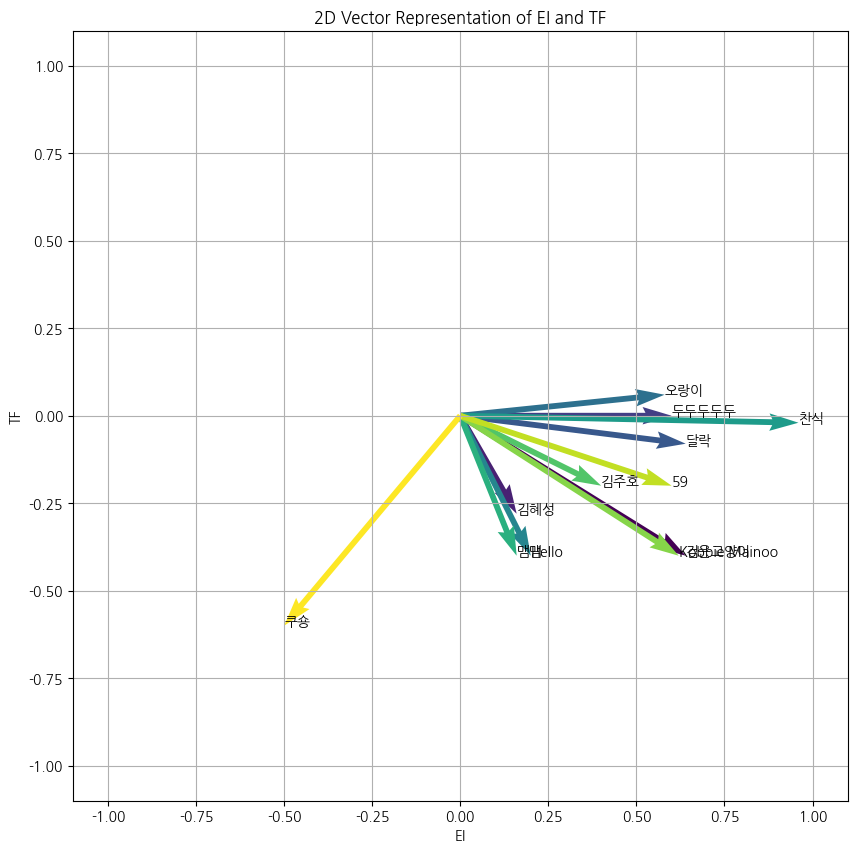

In [ ]:
# EI와 TF만 사용
data_2d = df_[['EI', 'TF']].to_numpy()
names_2d = df_['Name'].tolist()

fig, ax = plt.subplots(figsize=(10, 10))

# 모든 벡터의 시작점 = (0,0)
origin_2d = np.zeros(data_2d.shape)

# 색상
colors = plt.cm.viridis(
    np.linspace(0, 1, len(data_2d))
)

# 벡터 그리기
ax.quiver(
    origin_2d[:, 0],
    origin_2d[:, 1],
    data_2d[:, 0],
    data_2d[:, 1],
    color=colors,
    angles='xy',
    scale_units='xy',
    scale=1
)

# 이름 표시
for i, (x, y) in enumerate(data_2d):
    ax.text(x, y, names_2d[i])

ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])

ax.set_xlabel('EI')
ax.set_ylabel('TF')
ax.set_title('2D Vector Representation of EI and TF')

ax.grid()
plt.show()

In [ ]:
# EI, TF 2차원 데이터
data_2d = df_[['EI', 'TF']].to_numpy()
names_2d = df_['Name'].tolist()

# 쿠숑의 위치 찾기
self_idx = df_[df_['Name'] == '쿠숑'].index[0]

# 쿠숑 벡터
self_vector = data_2d[self_idx]

print("쿠숑 벡터:", self_vector)
print()

# 쿠숑과 다른 학생들의 내적 계산
for i in range(len(data_2d)):
    if i == self_idx:
        continue

    dot_product = np.dot(self_vector, data_2d[i])

    print(f"쿠숑 - {names_2d[i]}: {dot_product:.2f}")

쿠숑 벡터: [-0.5 -0.6]

쿠숑 - 검은고양이: -0.08
쿠숑 - 김혜성: 0.09
쿠숑 - 두두두두두: -0.30
쿠숑 - 달락: -0.27
쿠숑 - 오랑이: -0.33
쿠숑 - Hello: 0.14
쿠숑 - 찬식: -0.47
쿠숑 - 맴맴: 0.16
쿠숑 - 김주호: -0.08
쿠숑 - Kobbie Mainoo: -0.07
쿠숑 - 59: -0.18


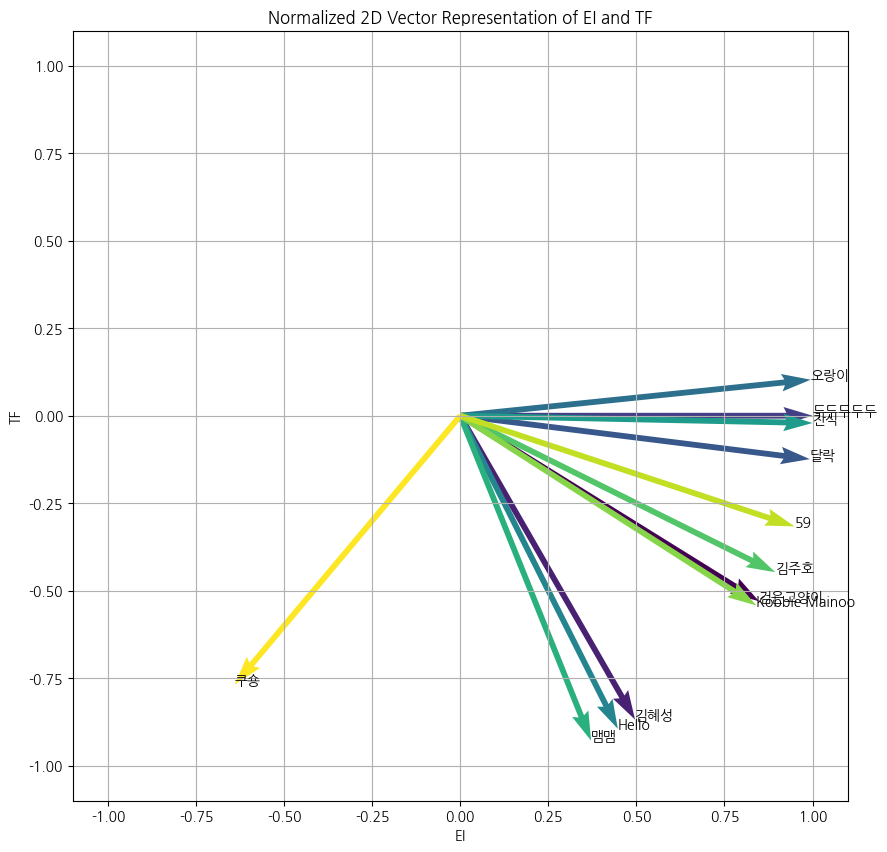

In [ ]:
# EI와 TF 데이터
data_2d = df_[['EI', 'TF']].to_numpy()
names_2d = df_['Name'].tolist()

# 각 벡터의 크기 계산
norms = np.linalg.norm(data_2d, axis=1, keepdims=True)

# 정규화
data_2d_norm = data_2d / norms

# 그래프
fig, ax = plt.subplots(figsize=(10, 10))

# 원점
origin_2d = np.zeros(data_2d_norm.shape)

# 색상
colors = plt.cm.viridis(
    np.linspace(0, 1, len(data_2d_norm))
)

# 정규화된 벡터 그리기
ax.quiver(
    origin_2d[:, 0],
    origin_2d[:, 1],
    data_2d_norm[:, 0],
    data_2d_norm[:, 1],
    color=colors,
    angles='xy',
    scale_units='xy',
    scale=1
)

# 이름 표시
for i, (x, y) in enumerate(data_2d_norm):
    ax.text(x, y, names_2d[i])

# 범위
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])

ax.set_xlabel('EI')
ax.set_ylabel('TF')
ax.set_title('Normalized 2D Vector Representation of EI and TF')

ax.grid()
plt.show()

In [ ]:
# 정규화된 데이터 사용
# data_2d_norm은 앞에서 이미 만든 상태

# 쿠숑의 위치
self_idx = names_2d.index('쿠숑')

# 쿠숑의 정규화된 벡터
self_vector_norm = data_2d_norm[self_idx]

print("쿠숑의 정규화된 벡터:", self_vector_norm)
print()

# 내적 계산
results_norm = []

for i in range(len(data_2d_norm)):
    if i == self_idx:
        continue

    # 정규화된 벡터끼리 내적
    dot_product = np.dot(self_vector_norm, data_2d_norm[i])

    results_norm.append({
        'Name': names_2d[i],
        'Normalized Dot Product': dot_product
    })

# 표로 만들기
dot_norm_df = pd.DataFrame(results_norm)

# 소수 둘째 자리까지
dot_norm_df['Normalized Dot Product'] = \
    dot_norm_df['Normalized Dot Product'].round(2)

dot_norm_df
# 가장 큰 내적
max_row = dot_norm_df.loc[
    dot_norm_df['Normalized Dot Product'].idxmax()
]

# 가장 작은 내적
min_row = dot_norm_df.loc[
    dot_norm_df['Normalized Dot Product'].idxmin()
]

# 0에 가장 가까운 내적
zero_row = dot_norm_df.loc[
    dot_norm_df['Normalized Dot Product'].abs().idxmin()
]

print("가장 큰 내적:")
print(max_row)

print("\n가장 작은 내적:")
print(min_row)

print("\n0에 가장 가까운 내적:")
print(zero_row)

쿠숑의 정규화된 벡터: [-0.6401844  -0.76822128]

가장 큰 내적:
Name                        맴맴
Normalized Dot Product    0.48
Name: 7, dtype: object

가장 작은 내적:
Name                       오랑이
Normalized Dot Product   -0.72
Name: 4, dtype: object

0에 가장 가까운 내적:
Name                      Kobbie Mainoo
Normalized Dot Product            -0.12
Name: 9, dtype: object


In [ ]:
# EI, NS, TF, JP 4개 특징 사용
data_4d = df_[['EI', 'NS', 'TF', 'JP']].to_numpy()
names_4d = df_['Name'].tolist()

# 쿠숑 위치
self_idx = names_4d.index('쿠숑')

# 쿠숑의 4차원 벡터
self_vector_4d = data_4d[self_idx]

print("쿠숑의 4차원 벡터:", self_vector_4d)

쿠숑의 4차원 벡터: [-0.5  0.4 -0.6 -0.5]


In [ ]:
results_4d = []

for i in range(len(data_4d)):
    if i == self_idx:
        continue

    # 4차원 벡터 내적
    dot_product = np.dot(self_vector_4d, data_4d[i])

    results_4d.append({
        'Name': names_4d[i],
        'Dot Product': dot_product
    })

dot_4d_df = pd.DataFrame(results_4d)

dot_4d_df['Dot Product'] = dot_4d_df['Dot Product'].round(2)

dot_4d_df

,Name,Dot Product
0,검은고양이,-0.29
1,김혜성,0.24
2,두두두두두,-0.85
3,달락,-0.21
4,오랑이,-0.67
5,Hello,0.00
6,찬식,-0.47
7,맴맴,-0.14
8,김주호,-0.46
9,Kobbie Mainoo,0.32


In [ ]:
# 가장 큰 내적
max_4d = dot_4d_df.loc[
    dot_4d_df['Dot Product'].idxmax()
]

# 가장 작은 내적
min_4d = dot_4d_df.loc[
    dot_4d_df['Dot Product'].idxmin()
]

# 0에 가장 가까운 내적
zero_4d = dot_4d_df.loc[
    dot_4d_df['Dot Product'].abs().idxmin()
]

print("가장 큰 내적:")
print(max_4d)

print("\n가장 작은 내적:")
print(min_4d)

print("\n0에 가장 가까운 내적:")
print(zero_4d)

가장 큰 내적:
Name           Kobbie Mainoo
Dot Product             0.32
Name: 9, dtype: object

가장 작은 내적:
Name           두두두두두
Dot Product    -0.85
Name: 2, dtype: object

0에 가장 가까운 내적:
Name           Hello
Dot Product      0.0
Name: 5, dtype: object


In [ ]:
# EI, NS, TF, JP 4차원 벡터
data_4d = df_[['EI', 'NS', 'TF', 'JP']].to_numpy()
names_4d = df_['Name'].tolist()

# 쿠숑 위치
self_idx = names_4d.index('쿠숑')

# 쿠숑의 원래 4차원 벡터
self_vector_4d = data_4d[self_idx]

print("쿠숑의 원래 벡터:", self_vector_4d)
# 각 벡터의 길이 계산
norms_4d = np.linalg.norm(data_4d, axis=1, keepdims=True)

# 길이로 나누어서 정규화
data_4d_norm = data_4d / norms_4d

# 쿠숑의 정규화된 벡터
self_vector_4d_norm = data_4d_norm[self_idx]

print("쿠숑의 정규화된 벡터:", self_vector_4d_norm)
results_4d_norm = []

for i in range(len(data_4d_norm)):
    if i == self_idx:
        continue

    # 정규화된 4차원 벡터의 내적
    dot_product = np.dot(
        self_vector_4d_norm,
        data_4d_norm[i]
    )

    results_4d_norm.append({
        'Name': names_4d[i],
        'Normalized Dot Product': dot_product
    })

dot_4d_norm_df = pd.DataFrame(results_4d_norm)

dot_4d_norm_df['Normalized Dot Product'] = \
    dot_4d_norm_df['Normalized Dot Product'].round(2)

dot_4d_norm_df

쿠숑의 원래 벡터: [-0.5  0.4 -0.6 -0.5]
쿠숑의 정규화된 벡터: [-0.49507377  0.39605902 -0.59408853 -0.49507377]


,Name,Normalized Dot Product
0,검은고양이,-0.34
1,김혜성,0.58
2,두두두두두,-0.70
3,달락,-0.25
4,오랑이,-0.84
5,Hello,0.00
6,찬식,-0.48
7,맴맴,-0.22
8,김주호,-0.59
9,Kobbie Mainoo,0.30
